In [21]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Add, Flatten, Dense, Input, MaxPooling2D, Rescaling
import matplotlib.pyplot as plt
import numpy as np
import PIL

In [5]:
import pathlib

trainDirictory = pathlib.Path("train").with_suffix('')
validationDir = pathlib.Path("valid").with_suffix('')

trainImageCount = len(list(trainDirictory.glob('*/*.jpg')))
validationImageCount = len(list(validationDir.glob('*/*.jpg')))

print("Number of images in training data : ", trainImageCount)
print("Number of images in validation data : ", validationImageCount)

Number of images in training data :  7213
Number of images in validation data :  1543


In [6]:
ImageBatchSize = 32
dimension = 180

In [7]:
trainingDataSet = tf.keras.utils.image_dataset_from_directory(
  trainDirictory,
  image_size=(dimension, dimension),
  batch_size=ImageBatchSize)

validationDataSet = tf.keras.utils.image_dataset_from_directory(
  validationDir,
  image_size=(dimension, dimension),
  batch_size=ImageBatchSize)

Found 7213 files belonging to 11 classes.
Found 1543 files belonging to 11 classes.


In [8]:
# The training classes
classNames = validationDataSet.class_names
classNames

['creamy_paste',
 'diced',
 'floured',
 'grated',
 'juiced',
 'jullienne',
 'mixed',
 'other',
 'peeled',
 'sliced',
 'whole']

In [9]:
# Tuning data for efficieny
trainingDataSet = trainingDataSet.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
validationDataSet = validationDataSet.cache().prefetch(buffer_size=tf.data.AUTOTUNE)

In [10]:
numClasses = len(classNames)

original_model = Sequential([
  tf.keras.layers.Rescaling(1./255, input_shape=(dimension, dimension, 3)),
  tf.keras.layers.Conv2D(16, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(numClasses)
])

original_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [11]:
epochs=10
original_history = original_model.fit(
  trainingDataSet,
  validation_data=validationDataSet,
  epochs=epochs
)

Epoch 1/10
226/226 [==============================] - 31s 39ms/step - loss: 2.2443 - accuracy: 0.1880 - val_loss: 2.1172 - val_accuracy: 0.2262
Epoch 2/10
226/226 [==============================] - 5s 21ms/step - loss: 2.0080 - accuracy: 0.2931 - val_loss: 2.0428 - val_accuracy: 0.2754
Epoch 3/10
226/226 [==============================] - 5s 20ms/step - loss: 1.7695 - accuracy: 0.3813 - val_loss: 1.9660 - val_accuracy: 0.3163
Epoch 4/10
226/226 [==============================] - 5s 22ms/step - loss: 1.4168 - accuracy: 0.5177 - val_loss: 2.0895 - val_accuracy: 0.3208
Epoch 5/10
226/226 [==============================] - 5s 22ms/step - loss: 0.9395 - accuracy: 0.6828 - val_loss: 2.3891 - val_accuracy: 0.3266
Epoch 6/10
226/226 [==============================] - 5s 20ms/step - loss: 0.5498 - accuracy: 0.8173 - val_loss: 3.1034 - val_accuracy: 0.3091
Epoch 7/10
226/226 [==============================] - 5s 22ms/step - loss: 0.3038 - accuracy: 0.9056 - val_loss: 3.6657 - val_accuracy: 0.305

# Data augumentation

In [12]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip('horizontal'),
  tf.keras.layers.RandomTranslation(height_factor=0.1, width_factor=0.1),
  tf.keras.layers.RandomZoom(0.2),
  tf.keras.layers.RandomZoom(height_factor=0.2, width_factor=0.2),
  tf.keras.layers.RandomContrast(factor=0.2)
])

data_augmented_model = Sequential([
  data_augmentation,
  tf.keras.layers.Rescaling(1./255, input_shape=(dimension, dimension, 3)),
  tf.keras.layers.Conv2D(16, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(numClasses)
])

data_augmented_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [13]:
epochs=10
augmented_history = data_augmented_model.fit(
  trainingDataSet,
  validation_data=validationDataSet,
  epochs=epochs
)

Epoch 1/10
226/226 [==============================] - 10s 27ms/step - loss: 2.2438 - accuracy: 0.1843 - val_loss: 2.1396 - val_accuracy: 0.2184
Epoch 2/10
226/226 [==============================] - 5s 24ms/step - loss: 2.0816 - accuracy: 0.2537 - val_loss: 2.0979 - val_accuracy: 0.2424
Epoch 3/10
226/226 [==============================] - 6s 26ms/step - loss: 1.9958 - accuracy: 0.2789 - val_loss: 2.1169 - val_accuracy: 0.2521
Epoch 4/10
226/226 [==============================] - 6s 24ms/step - loss: 1.9322 - accuracy: 0.3050 - val_loss: 1.8835 - val_accuracy: 0.3169
Epoch 5/10
226/226 [==============================] - 5s 24ms/step - loss: 1.8758 - accuracy: 0.3294 - val_loss: 1.8944 - val_accuracy: 0.3221
Epoch 6/10
226/226 [==============================] - 6s 27ms/step - loss: 1.7921 - accuracy: 0.3632 - val_loss: 1.9097 - val_accuracy: 0.3325
Epoch 7/10
226/226 [==============================] - 5s 24ms/step - loss: 1.7617 - accuracy: 0.3732 - val_loss: 1.7955 - val_accuracy: 0.357

# Different drop rates

In [14]:
drop_rates_model = Sequential([
  tf.keras.layers.Rescaling(1./255, input_shape=(dimension, dimension, 3)),
  tf.keras.layers.Conv2D(16, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Dropout(0.2),

  tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Dropout(0.3),

  tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.Dropout(0.4),

  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dropout(0.5),
  tf.keras.layers.Dense(numClasses)
])

drop_rates_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [15]:
epochs=10
drop_rates_history = drop_rates_model.fit(
  trainingDataSet,
  validation_data=validationDataSet,
  epochs=epochs
)

Epoch 1/10
226/226 [==============================] - 9s 29ms/step - loss: 2.4404 - accuracy: 0.1228 - val_loss: 2.3586 - val_accuracy: 0.1536
Epoch 2/10
226/226 [==============================] - 7s 29ms/step - loss: 2.3388 - accuracy: 0.1386 - val_loss: 2.2812 - val_accuracy: 0.2022
Epoch 3/10
226/226 [==============================] - 6s 28ms/step - loss: 2.2320 - accuracy: 0.1872 - val_loss: 2.2229 - val_accuracy: 0.2067
Epoch 4/10
226/226 [==============================] - 6s 27ms/step - loss: 2.1806 - accuracy: 0.2087 - val_loss: 2.1761 - val_accuracy: 0.1996
Epoch 5/10
226/226 [==============================] - 6s 28ms/step - loss: 2.1527 - accuracy: 0.2179 - val_loss: 2.1561 - val_accuracy: 0.2191
Epoch 6/10
226/226 [==============================] - 6s 28ms/step - loss: 2.1182 - accuracy: 0.2351 - val_loss: 2.1424 - val_accuracy: 0.2495
Epoch 7/10
226/226 [==============================] - 6s 27ms/step - loss: 2.0885 - accuracy: 0.2414 - val_loss: 2.0894 - val_accuracy: 0.2625

# Batch Normalization

In [16]:
batch_normalization_model = Sequential([
  tf.keras.layers.Rescaling(1./255, input_shape=(dimension, dimension, 3)),
  tf.keras.layers.Conv2D(16, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.Conv2D(32, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.Conv2D(64, 3, padding='same', activation='relu'),
  tf.keras.layers.MaxPooling2D(),
  tf.keras.layers.BatchNormalization(),
  tf.keras.layers.Flatten(),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(128, activation='relu'),
  tf.keras.layers.Dense(numClasses)
])

batch_normalization_model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [17]:
epochs=10
batch_normalization_history = batch_normalization_model.fit(
  trainingDataSet,
  validation_data=validationDataSet,
  epochs=epochs
)

Epoch 1/10
226/226 [==============================] - 8s 25ms/step - loss: 2.5049 - accuracy: 0.1866 - val_loss: 2.8065 - val_accuracy: 0.1231
Epoch 2/10
226/226 [==============================] - 5s 23ms/step - loss: 2.0991 - accuracy: 0.2378 - val_loss: 2.5559 - val_accuracy: 0.1834
Epoch 3/10
226/226 [==============================] - 5s 23ms/step - loss: 1.9570 - accuracy: 0.2907 - val_loss: 2.2378 - val_accuracy: 0.2184
Epoch 4/10
226/226 [==============================] - 5s 24ms/step - loss: 1.8344 - accuracy: 0.3370 - val_loss: 2.2439 - val_accuracy: 0.2657
Epoch 5/10
226/226 [==============================] - 5s 23ms/step - loss: 1.6462 - accuracy: 0.4084 - val_loss: 2.3285 - val_accuracy: 0.2664
Epoch 6/10
226/226 [==============================] - 5s 24ms/step - loss: 1.4211 - accuracy: 0.4840 - val_loss: 2.0773 - val_accuracy: 0.3007
Epoch 7/10
226/226 [==============================] - 5s 24ms/step - loss: 1.1894 - accuracy: 0.5758 - val_loss: 2.4212 - val_accuracy: 0.2890

# Inception module

In [18]:
from tensorflow.keras import layers, models

def inceptionModule(inputTensor, filters1x1, filters3x3, filtersPoolProj):
    conv1x1 = layers.Conv2D(filters1x1, (1, 1), padding='same', activation='relu')(inputTensor)
    conv3x3 = layers.Conv2D(filters3x3, (3, 3), padding='same', activation='relu')(inputTensor)
    maxPool = layers.MaxPooling2D((3, 3), strides=(1, 1), padding='same')(inputTensor)
    poolProj = layers.Conv2D(filtersPoolProj, (1, 1), padding='same', activation='relu')(maxPool)
    output = layers.concatenate([conv1x1, conv3x3, poolProj], axis=-1)

    return output

In [19]:
inputLayer = layers.Input(shape=[dimension, dimension, 3])
normLayer = layers.Rescaling(1./255)(inputLayer)
convLayer1 = layers.Conv2D(16, (3, 3), activation='relu')(normLayer)
poolLayer1 = layers.MaxPooling2D((2, 2))(convLayer1)
convLayer2 = layers.Conv2D(32, (3, 3), activation='relu')(poolLayer1)
poolLayer2 = layers.MaxPooling2D((2, 2))(convLayer2)
convLayer3 = layers.Conv2D(64, (3, 3), activation='relu')(poolLayer2)

inceptionLayer1 = inceptionModule(convLayer3, 64, 128, 64)

poolLayer3 = layers.MaxPooling2D((2, 2))(inceptionLayer1)

flattenLayer = layers.Flatten()(poolLayer3)
denseLayer1 = layers.Dense(128, activation='relu')(flattenLayer)
dropoutLayer = layers.Dropout(0.2)(denseLayer1)
outputLayer = layers.Dense(numClasses, activation='softmax')(dropoutLayer)

inception_model = models.Model(inputs=inputLayer, outputs=outputLayer)

inception_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

inception_history = inception_model.fit(
    trainingDataSet,
    validation_data=validationDataSet,
    epochs=10
)

Epoch 1/10
226/226 [==============================] - 14s 41ms/step - loss: 2.3116 - accuracy: 0.1847 - val_loss: 2.1119 - val_accuracy: 0.2346
Epoch 2/10
226/226 [==============================] - 8s 35ms/step - loss: 2.0930 - accuracy: 0.2436 - val_loss: 2.0299 - val_accuracy: 0.2793
Epoch 3/10
226/226 [==============================] - 8s 34ms/step - loss: 1.9932 - accuracy: 0.2885 - val_loss: 1.9727 - val_accuracy: 0.2988
Epoch 4/10
226/226 [==============================] - 8s 35ms/step - loss: 1.8547 - accuracy: 0.3456 - val_loss: 1.9481 - val_accuracy: 0.3046
Epoch 5/10
226/226 [==============================] - 8s 35ms/step - loss: 1.7065 - accuracy: 0.3925 - val_loss: 1.9032 - val_accuracy: 0.3305
Epoch 6/10
226/226 [==============================] - 8s 34ms/step - loss: 1.4805 - accuracy: 0.4790 - val_loss: 1.9422 - val_accuracy: 0.3344
Epoch 7/10
226/226 [==============================] - 8s 35ms/step - loss: 1.2433 - accuracy: 0.5640 - val_loss: 1.9597 - val_accuracy: 0.350

# Residual connections

In [22]:
def residual_block(x, filters):
    shortcut = x
    x = Conv2D(filters, (3, 3), padding='same', activation='relu')(x)
    x = Conv2D(filters, (3, 3), padding='same')(x)
    x = Add()([shortcut, x])
    x = tf.keras.layers.Activation('relu')(x)
    return x

inputs = Input(shape=(dimension, dimension, 3))
x = Rescaling(1./255)(inputs)
x = Conv2D(16, (3, 3), padding='same', activation='relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(32, (3, 3), padding='same', activation='relu')(x)
x = MaxPooling2D((2, 2))(x)
x = Conv2D(64, (3, 3), padding='same', activation='relu')(x)
x = MaxPooling2D((2, 2))(x)
x = residual_block(x, filters=64)
x = Flatten()(x)
x = Dense(128, activation='relu')(x)
outputs = Dense(numClasses, activation='softmax')(x)

residual_model = tf.keras.Model(inputs=inputs, outputs=outputs)

residual_model.compile(optimizer='adam',
                       loss='sparse_categorical_crossentropy',
                       metrics=['accuracy'])

In [23]:
residual_history = residual_model.fit(trainingDataSet,
                                      validation_data=validationDataSet,
                                      epochs=10)

Epoch 1/10
226/226 [==============================] - 8s 25ms/step - loss: 2.2988 - accuracy: 0.1701 - val_loss: 2.1871 - val_accuracy: 0.2054
Epoch 2/10
226/226 [==============================] - 5s 23ms/step - loss: 2.1421 - accuracy: 0.2170 - val_loss: 2.0795 - val_accuracy: 0.2391
Epoch 3/10
226/226 [==============================] - 5s 24ms/step - loss: 1.9786 - accuracy: 0.2949 - val_loss: 2.0781 - val_accuracy: 0.2670
Epoch 4/10
226/226 [==============================] - 5s 24ms/step - loss: 1.7767 - accuracy: 0.3692 - val_loss: 1.9692 - val_accuracy: 0.3156
Epoch 5/10
226/226 [==============================] - 6s 24ms/step - loss: 1.4986 - accuracy: 0.4794 - val_loss: 1.9773 - val_accuracy: 0.3143
Epoch 6/10
226/226 [==============================] - 5s 24ms/step - loss: 1.1299 - accuracy: 0.6126 - val_loss: 2.3271 - val_accuracy: 0.2949
Epoch 7/10
226/226 [==============================] - 6s 25ms/step - loss: 0.6750 - accuracy: 0.7778 - val_loss: 2.7804 - val_accuracy: 0.2845

# The best model is Data Augumentation

In [24]:
data_augmented_model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 sequential_1 (Sequential)   (None, 180, 180, 3)       0         
                                                                 
 rescaling_1 (Rescaling)     (None, 180, 180, 3)       0         
                                                                 
 conv2d_3 (Conv2D)           (None, 180, 180, 16)      448       
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 90, 90, 16)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 90, 90, 32)        4640      
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 45, 45, 32)        0         
 g2D)                                                 

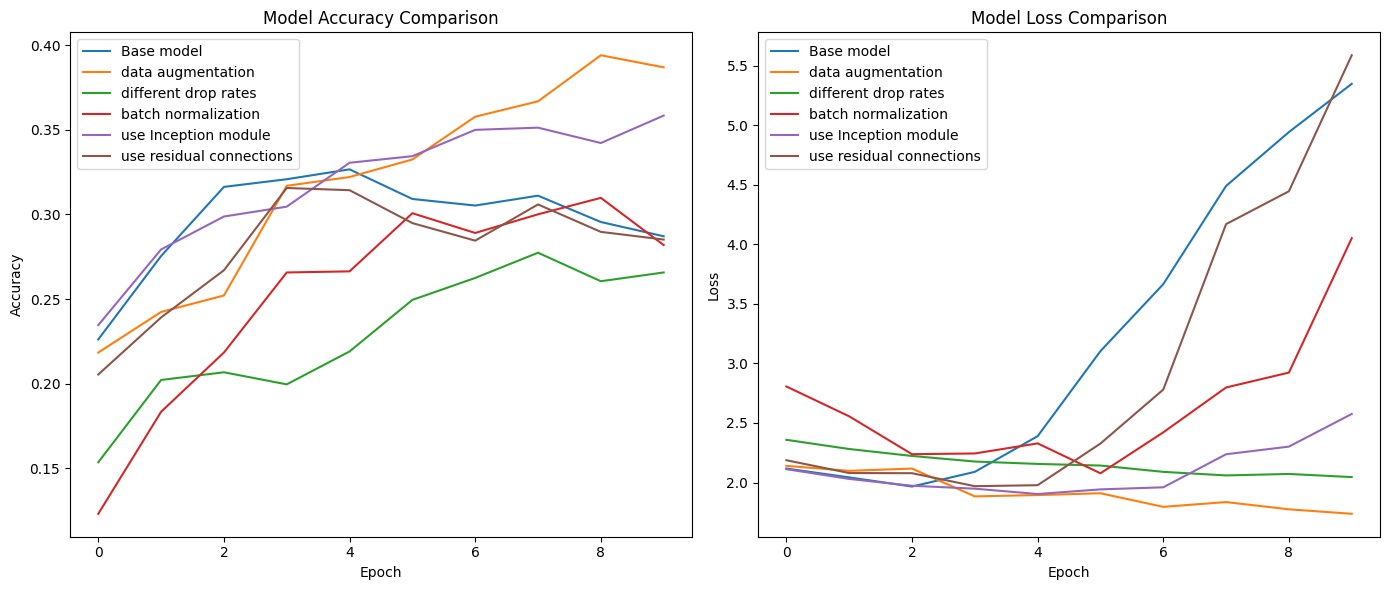

In [25]:
historyNames = ["Base model", "data augmentation", "different drop rates", "batch normalization", "use Inception module", "use residual connections"]
historyObjects = [original_history, augmented_history, drop_rates_history, batch_normalization_history, inception_history, residual_history]

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
for i, history in enumerate(historyObjects):
      plt.plot(history.history['val_accuracy'], label=f'{historyNames[i]}')

plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend()

plt.subplot(1, 2, 2)
for i, history in enumerate(historyObjects):
    plt.plot(history.history['val_loss'], label=f'{historyNames[i]}')

plt.title('Model Loss Comparison')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend()

plt.tight_layout()
plt.show()

# From the above observation the data augumentation model is doing better job at the accuracy

In [26]:
data_augmented_model.save("saved_model.h5")

In [28]:
# Testing on the data to get results such as loss and accuracy
results = data_augmented_model.evaluate(validationDataSet)
print(f"Accuracy : {results[1]:.2f}  loss : {results[0]:.2f}")

49/49 [==============================] - 1s 15ms/step - loss: 1.7372 - accuracy: 0.3869
Accuracy : 0.39  loss : 1.74
